# Finding Key Sensors for Engine Health Monitoring

## Question
Which sensors consistently change as engines approach failure across all engines in the NASA FD001 dataset?

## Objective
Identify Sensors that may serve as indicators of engine degradation by comparing trends across the entire fleet.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
column_names=["engine_id","cycle"]+[f"setting_{i}" for i in range(1,4)]+[f"sensor_{i}" for i in range(1,22)]

df=pd.read_csv('../data/raw/train_FD001.txt',sep=r'\s+',header=None)

df.columns=column_names

In [4]:
engine_life= df.groupby("engine_id")["cycle"].max()

engine_life


engine_id
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64

In [7]:
df["max_cycle"]=df.groupby('engine_id')["cycle"].transform("max")

df["life_percent"]=(df["cycle"]/df["max_cycle"])*100

df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,life_percent
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,0.520833
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,1.041667
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,1.562500
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,2.083333
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,2.604167


In [18]:
candidate_sensors=['sensor_4','sensor_9','sensor_11','sensor_14','sensor_15']

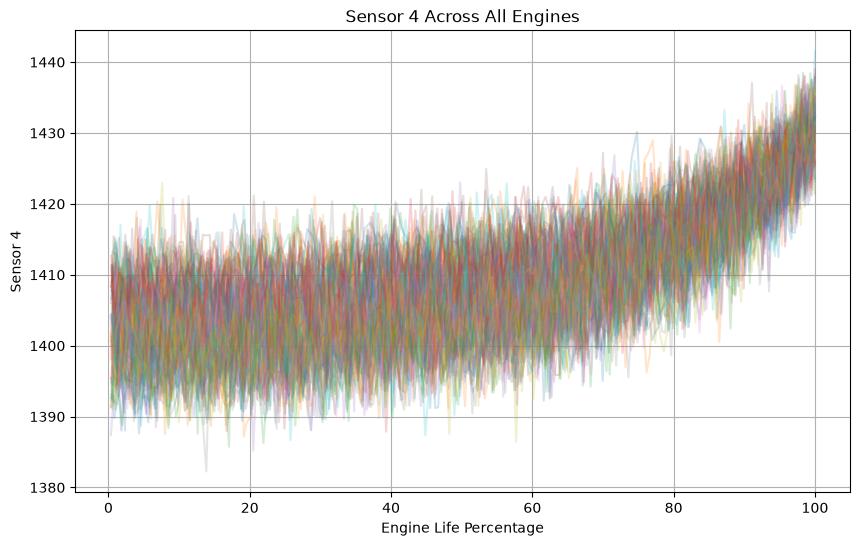

In [20]:
plt.figure(figsize=(10,6))

for engine in df["engine_id"].unique():
    engine_data = df[df["engine_id"]==engine]
    
    plt.plot(engine_data["life_percent"],engine_data["sensor_4"],alpha=0.2)
    
plt.title("Sensor 4 Across All Engines")
plt.xlabel("Engine Life Percentage")
plt.ylabel("Sensor 4")
plt.grid(True)

plt.savefig("../figures/07_sensor4_all_engines.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Observation: Sensor 4 values remain relatively stable until the engines life percentage reaches 40% where the values experience a slight increase until they reach 60% life percentage where there is a sharp increase until the end of the engines lifecycles. This indicates that Sensor 4 values changes throughout the engine life cycle which suggest it could be a good indicator of engine degradation.

<function matplotlib.pyplot.show(close=None, block=None)>

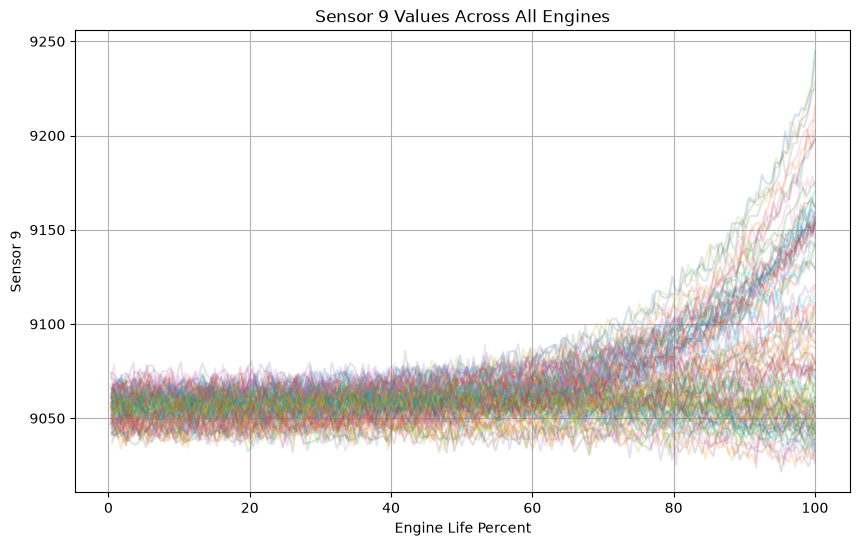

In [13]:
plt.figure(figsize=(10,6))

for engine in df["engine_id"].unique():
    engine_data= df[df["engine_id"]==engine]
    
    plt.plot(engine_data["life_percent"],engine_data["sensor_9"],alpha=0.2)
    
plt.title('Sensor 9 Values Across All Engines')
plt.xlabel('Engine Life Percent')
plt.ylabel('Sensor 9')
plt.grid('True')

plt.show


Observation:Through out the engines life sensor 9 values vary differently across engines, for some engines it remains fairly constant throughout their life cycles and while for others we see an increase in value when the engines cross over the 60% mark. This indicates that sensor 9 needs more evaluation befor we can determine if it would be a good candidate for determining enginr degradation.

<function matplotlib.pyplot.show(close=None, block=None)>

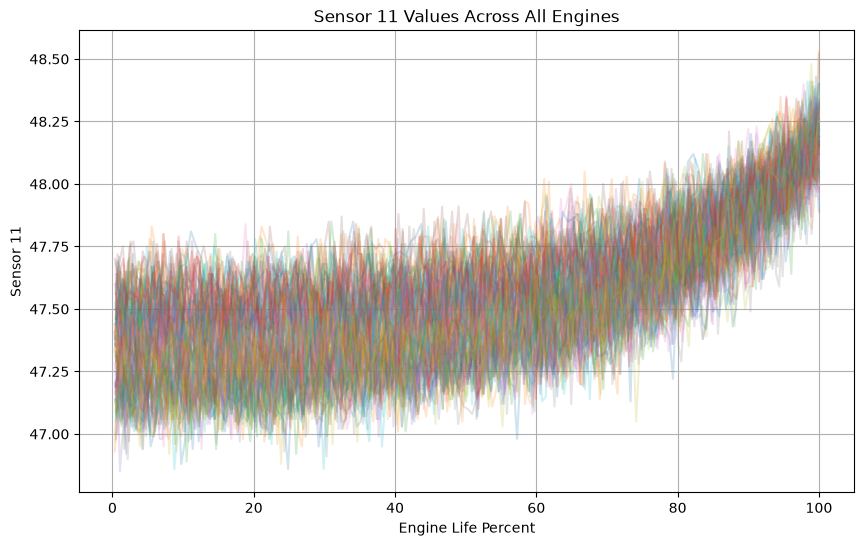

In [21]:
plt.figure(figsize=(10,6))

for engine in df["engine_id"].unique():
    engine_data= df[df["engine_id"]==engine]
    
    plt.plot(engine_data["life_percent"],engine_data["sensor_11"],alpha=0.2)
    
plt.title('Sensor 11 Values Across All Engines')
plt.xlabel('Engine Life Percent')
plt.ylabel('Sensor 11')
plt.grid('True')

plt.savefig("../figures/08_sensor11_all_engines.png",
            dpi=300,
            bbox_inches="tight")

plt.show

Observation:Observation: Sensor 11 values remain relatively stable until the engines life percentage reaches 40% where the values experience a slight increase until they reach 60% life percentage where there is a sharp increase until the end of the engines lifecycles. This indicates that Sensor 11 values changes throughout the engine life cycle which suggest it could be a good indicator of engine degradation.

<function matplotlib.pyplot.show(close=None, block=None)>

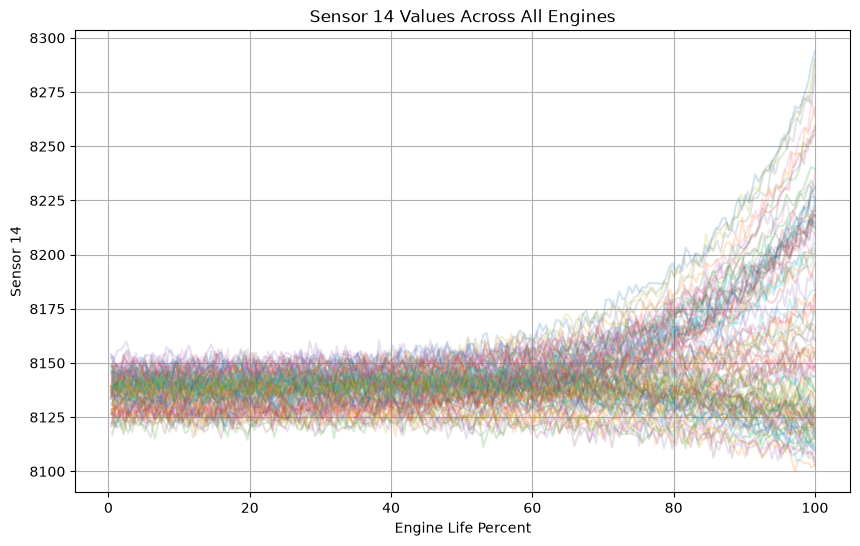

In [15]:
plt.figure(figsize=(10,6))

for engine in df["engine_id"].unique():
    engine_data= df[df["engine_id"]==engine]
    
    plt.plot(engine_data["life_percent"],engine_data["sensor_14"],alpha=0.2)
    
plt.title('Sensor 14 Values Across All Engines')
plt.xlabel('Engine Life Percent')
plt.ylabel('Sensor 14')
plt.grid('True')

plt.show

Observation:Through out the engines life sensor 14 values vary differently across engines, for some engines it remains fairly constant throughout their life cycles and while for others we see an increase in value when the engines cross over the 60% mark. This indicates that sensor 14 needs more evaluation befor we can determine if it would be a good candidate for determining enginr degradation.

<function matplotlib.pyplot.show(close=None, block=None)>

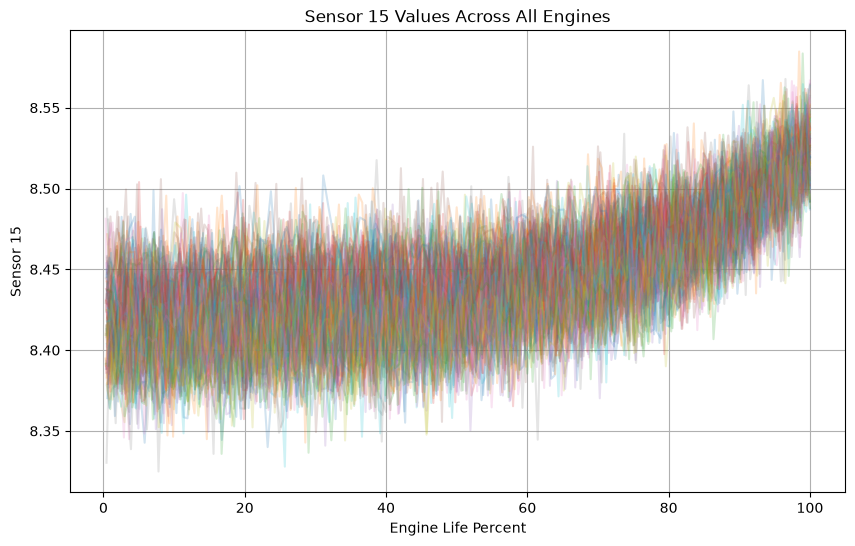

In [22]:
plt.figure(figsize=(10,6))

for engine in df["engine_id"].unique():
    engine_data= df[df["engine_id"]==engine]
    
    plt.plot(engine_data["life_percent"],engine_data["sensor_15"],alpha=0.2)
    
plt.title('Sensor 15 Values Across All Engines')
plt.xlabel('Engine Life Percent')
plt.ylabel('Sensor 15')
plt.grid('True')

plt.savefig("../figures/09_sensor15_all_engines.png",
            dpi=300,
            bbox_inches="tight")
plt.show

Observation:Observation: Sensor 15 values remain relatively stable until the engines life percentage reaches 40% where the values experience a slight increase until they reach 60% life percentage where there is a sharp increase until the end of the engines lifecycles. This indicates that Sensor 15 values changes throughout the engine life cycle which suggest it could be a good indicator of engine degradation.

In [19]:
for sensor in candidate_sensors:
    correlation=df["life_percent"].corr(df[sensor])
    print(f"{sensor}:{correlation:.3f}")

sensor_4:0.712
sensor_9:0.449
sensor_11:0.727
sensor_14:0.363
sensor_15:0.673


|Sensor|Standard Deviation|Correlation With Engine Life Percentage|Visual Trend|Reccomendation|
|------|------------------|------------------------------------|------------|--------------|
|Sensor 4|9.00|0.712|Strong increase|Excellent Candidate|
|Sensor 9|22.08|0.49|Mixed|Needs More Study|
|Sensor 11|0.27|0.727|Strong increase|Excellent Candidate|
|Sensor 14|19.08|0.363|Mixed|Needs More Study|
|Sensor 15|0.038|0.673|Moderate increase|Good Candidate|

## Conclusion

The analysis demonstrates that sensor variability alone is not sufficient for identifying useful engine health indicators. Sensors 9 and 14 exhibited the highest standard deviations among the five sensors analyzed but showed weaker and less consistent relationships with normalized engine life.

In contrast, Sensors 11, 4, and 15 demonstrated stronger positive relationships with engine aging. Sensor 11 had the strongest correlation (r = 0.727), followed by Sensor 4 (r = 0.712) and Sensor 15 (r = 0.673).

The visual analysis also showed that Sensors 4, 11, and 15 generally become more responsive during the later stages of engine life, particularly after approximately 60% normalized life.

These results suggest that Sensors 4, 11, and 15 are promising candidates for further degradation analysis. However, the current analysis is exploratory, and additional statistical analysis across all 21 sensors is necessary before determining which sensors are the most reliable indicators of engine degradation.